In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
from src.util import read_video_frames, display_image, draw_bounding_box, render_scene, get_character_placeholder, pointcloud_to_mesh
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, get_masks_from_image_chunks
from src.operations3d import reconstruct_meshes_for_chunks, adjust_meshes_by_chunk_rotation

In [40]:
video_path = "vids/hallway_horizontal.mp4"
frame_index = 120

object_class = "wooden_cabinet"

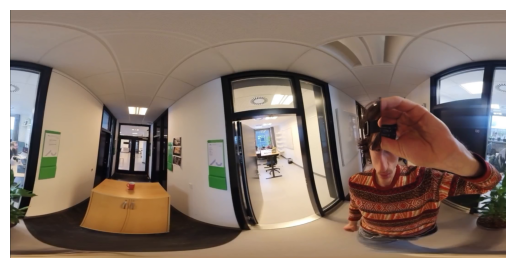

In [7]:
input_frame = read_video_frames(video_path)[frame_index]

display_image(input_frame)

# Single Class

Get panorama 2dbb and get image chunk

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



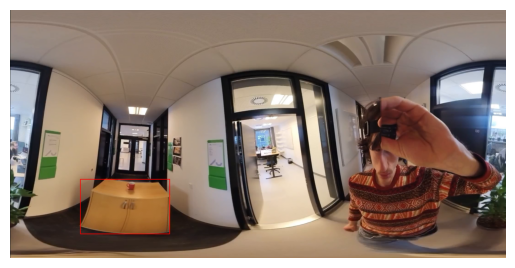

In [45]:
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class, use_gpu=True, threshold=0.7)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

display_image(frame_with_boxes)

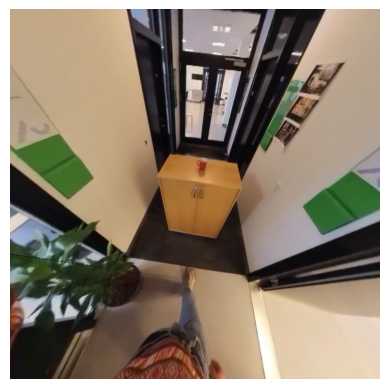

In [46]:
image_chunks = bounding_boxes_to_image_chunks(input_frame, bounding_boxes, orientation="horizontal")
display_image(image_chunks[0].image)

Get object masks

In [ ]:
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class, use_gpu=True)

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



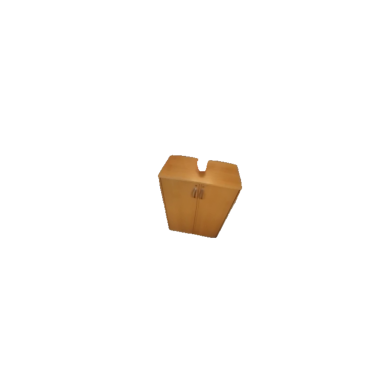

In [39]:
display_image(masks[0])

Generate meshes

In [68]:
meshes = reconstruct_meshes_for_chunks(image_chunks, masks)

Running sam3d in conda environment 'sam3d-objects'...
nvdiffrast:  True
[SPARSE][CONV] spconv algo: auto
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L4" (22 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/ucloud/.cache/warp/1.12.0
INFO- Loaded 6158 vertices and 12305 faces.


0% done 
50% done 
100% done 
Saved mesh 1/1 to temp/sam3d_output/reconstructed_mesh_0.glb
Generated 1 meshes



In [69]:
import open3d as o3d
o3d.io.write_triangle_mesh("output/cupboard.glb", meshes[0])

[Open3D WARNING] This file format does not support writing textures and uv coordinates. Consider using .obj


True

In [39]:
import trimesh
import open3d as o3d

scene = trimesh.load("output/cupboard.glb")
geom = list(scene.geometry.values())
cupboard_glb = o3d.geometry.TriangleMesh(vertices=o3d.utility.Vector3dVector(geom[0].vertices), triangles=o3d.utility.Vector3iVector(geom[0].faces))
meshes = [cupboard_glb]

In [70]:
adjusted_meshes = adjust_meshes_by_chunk_rotation(meshes, image_chunks)

In [61]:
import open3d as o3d
o3d.io.write_triangle_mesh("output/cupboard_adjusted.glb", adjusted_meshes[0])

[Open3D WARNING] This file format does not support writing textures and uv coordinates. Consider using .obj


True

Render Scene

In [71]:
import open3d as o3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])

scene_meshes = adjusted_meshes

render_scene(scene_meshes + [character_placeholder, coordinate_frame])

[Open3D WARNING] invalid color in PaintUniformColor, clipping to [0, 1]


# Multiple Classes

In [ ]:
from src.tracking import reconstruct_meshes_for_class

In [ ]:
cupboard_meshes = adjusted_meshes

In [ ]:
cup_meshes = reconstruct_meshes_for_class(input_frame, "cup")

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cuda
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes

Running ovseg in conda environment 'ovseg'...
Loading OV-Seg model...
OV-Seg model loaded.
Processed chunk 1/1
Saved 1 masks

Running sam3d in conda environment 'sam3d-objects'...
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L4" (22 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/ucloud/.cache/warp/1.12.0
[SPARSE][CONV] spconv algo: auto
Saved point cloud 1/1 to temp/sam3d_output/reconstructed_mesh_0.ply
Generated 1 point clouds



In [ ]:
o3d.io.write_triangle_mesh("output/cup.glb", cup_meshes[0])

True

In [ ]:
all_meshes = cupboard_meshes + cup_meshes

In [ ]:
import open3d as o3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])

scene_meshes = all_meshes

render_scene(scene_meshes + [character_placeholder, coordinate_frame])